## Simula Interacciones

# ¿Cómo funciona la simulación?

Para cada usuario:
  ├── 70% de sus interacciones → canciones de su género favorito
  └── 30% de sus interacciones → canciones de cualquier género

Para cada canción seleccionada:
  ├── Si es de su género favorito:
  │     like  60% | play 35% | skip  5%
  └── Si NO es de su género favorito:
        like  10% | play 40% | skip 50%

# Importaciones

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ITEMS_PATH = Path('/data/processed/items.csv')
if not ITEMS_PATH.exists():
	ITEMS_PATH = Path('../../data/processed/items.csv')
 
USERS_PATH = Path('/data/processed/users.csv')
if not USERS_PATH.exists():
	USERS_PATH = Path('../../data/processed/users.csv')
 
OUTPUT_PATH = Path('/data/processed/interactions.csv')
if not OUTPUT_PATH.exists():
	OUTPUT_PATH = Path('../../data/processed/interactions.csv')

N_INTERACTIONS_PER_USER = 50

# Carga de Datos

In [2]:
items = pd.read_csv(ITEMS_PATH)
users = pd.read_csv(USERS_PATH)

print(f'Canciones disponibles: {len(items):,}')
print(f'Usuarios disponibles:  {len(users):,}')

# Agrupar canciones por género para acelerar el sampling
items_por_genero = {
    genero: grupo['ITEM_ID'].tolist()
    for genero, grupo in items.groupby('genero')
}
todos_los_items = items['ITEM_ID'].tolist()

print(f'\nGéneros indexados: {len(items_por_genero)}')

Canciones disponibles: 114,000
Usuarios disponibles:  15,001

Géneros indexados: 114


# Funsiones de Simulación

In [3]:
def generar_timestamp(n: int) -> list:
    """Genera n timestamps aleatorios en el último año."""
    ahora = datetime.now()
    hace_un_año = ahora - timedelta(days=365)
    rango = int((ahora - hace_un_año).total_seconds())
    # Generamos n segundos aleatorios dentro del rango y los convertimos a timestamp
    return [int((hace_un_año + timedelta(seconds=random.randint(0, rango))).timestamp())
        for _ in range(n)
    ]

def seleccionar_cancion(generos_favoritos: list) -> tuple:
    """\n
    Selecciona una canción y determina si es del género favorito.\n
    Retorna (item_id, es_favorito)\n
    """
    # 70% de probabilidad de elegir una canción del(s) género(s) favorito(s)
    es_favorito = random.random() < 0.70   # 70% del género favorito

    if es_favorito:
        # Elegir aleatoriamente uno de los géneros favoritos del usuario
        genero = random.choice(generos_favoritos)
        # Tomar candidatos del índice por género, si no existe usar todos los items
        candidatos = items_por_genero.get(genero, todos_los_items)
        # Devolver un item aleatorio de ese conjunto y la bandera de favorito
        return random.choice(candidatos), True
    else:
        # Si no es favorito, elegir de entre todos los items disponibles
        return random.choice(todos_los_items), False

def asignar_tipo_interaccion(es_favorito: bool) -> str:
    """
    Asigna tipo de interacción según si la canción es del género favorito.\n
    """
    # Si es del género favorito, más probabilidad de 'like' que de 'skip'
    if es_favorito:
        return random.choices(['like', 'play', 'skip'], weights=[0.60, 0.35, 0.05])[0]
    else:
        # Si no es favorito, mayor probabilidad de 'skip'
        return random.choices(['like', 'play', 'skip'], weights=[0.10, 0.40, 0.50])[0]

print('Funciones de simulación definidas')

Funciones de simulación definidas


# Se generan Interacciones

In [4]:
interacciones = []

for _, usuario in users.iterrows():
    user_id          = usuario['USER_ID']
    generos_favoritos = usuario['genero_favorito'].split('|')
    timestamps        = sorted(generar_timestamp(N_INTERACTIONS_PER_USER))

    canciones_vistas = set()   # evitar interacciones duplicadas por usuario

    for ts in timestamps:
        item_id, es_favorito = seleccionar_cancion(generos_favoritos)

        # Si ya interactuó con esta canción, buscar otra
        intentos = 0
        while item_id in canciones_vistas and intentos < 10:
            item_id, es_favorito = seleccionar_cancion(generos_favoritos)
            intentos += 1

        canciones_vistas.add(item_id)
        tipo = asignar_tipo_interaccion(es_favorito)

        interacciones.append({
            'USER_ID'          : user_id,
            'ITEM_ID'          : item_id,
            'EVENT_TYPE'       : tipo,
            'TIMESTAMP'        : ts
        })

interactions = pd.DataFrame(interacciones)
print(f'Interacciones generadas: {len(interactions):,}')
interactions.head(10)

Interacciones generadas: 750,050


,USER_ID,ITEM_ID,EVENT_TYPE,TIMESTAMP
0,user_0001,04jV9kpwWbr4HHfxfK4sSu,like,1747033426
1,user_0001,7tQyxRUBcy0XVZbATedxBU,like,1747654585
2,user_0001,2ccCaAC8svYq42eUY6uZuv,play,1747705763
3,user_0001,5gXofLkTeHbGwIgulWNSG7,play,1747815192
4,user_0001,4CvQVmA1wVX4gKOJ7aQOZQ,skip,1747881813
5,user_0001,5wWRdIjndDOh1j4OXAPpdD,skip,1749732547
6,user_0001,0lIAAEd3YoxWdEgYEdlrdE,skip,1749959254
7,user_0001,3d3v5loMgJyAhAMlh2dULp,play,1750254531
8,user_0001,5Y1JDF28qQDml25pVadnzb,like,1750551014
9,user_0001,22IGm6PYN1THrPe1jFT5u6,play,1751497479


# Revisión

In [5]:
print('=== Resumen general ===')
print(f'Total interacciones: {len(interactions):,}')
print(f'Usuarios únicos: {interactions["USER_ID"].nunique():,}')
print(f'Canciones únicas tocadas: {interactions["ITEM_ID"].nunique():,}')

print(f'\n Distribución de EVENT_TYPE:')

print(interactions['EVENT_TYPE'].value_counts())
print(f'\nNulos: {interactions.isnull().sum().sum()}')

=== Resumen general ===
Total interacciones: 750,050
Usuarios únicos: 15,001
Canciones únicas tocadas: 89,639

 Distribución de EVENT_TYPE:
EVENT_TYPE
like    336725
play    273705
skip    139620
Name: count, dtype: int64

Nulos: 0


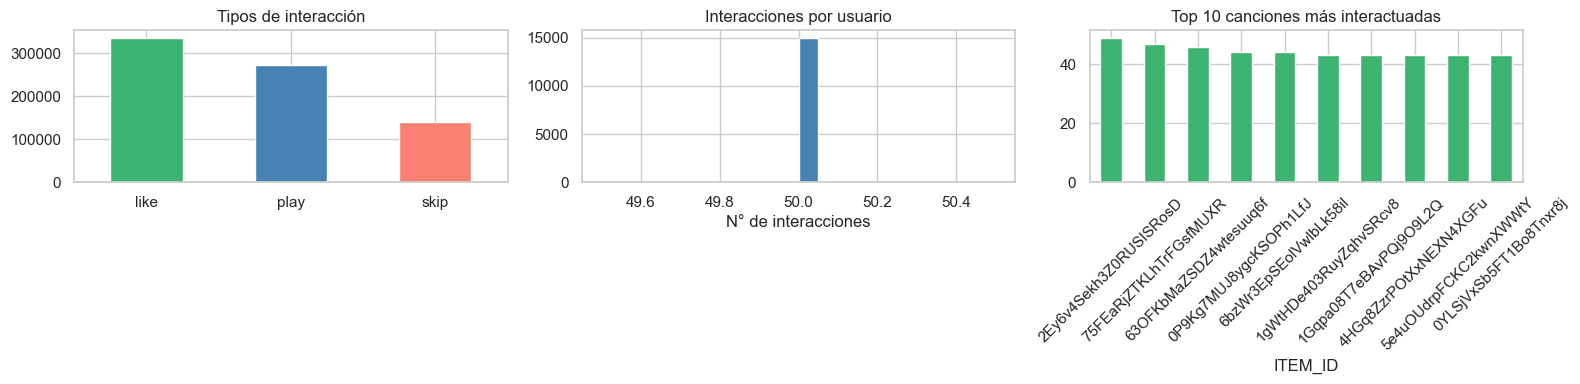

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de tipos de interacción
interactions['EVENT_TYPE'].value_counts().plot(
    kind='bar', ax=axes[0], color=['mediumseagreen', 'steelblue', 'salmon']
)
axes[0].set_title('Tipos de interacción')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Interacciones por usuario
ints_por_usuario = interactions.groupby('USER_ID').size()
axes[1].hist(ints_por_usuario, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Interacciones por usuario')
axes[1].set_xlabel('N° de interacciones')

# Canciones más populares (más interacciones)
top_canciones = (
    interactions[interactions['EVENT_TYPE'] != 'skip']
    .groupby('ITEM_ID').size()
    .sort_values(ascending=False)
    .head(10)
)
top_canciones.plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 10 canciones más interactuadas')
axes[2].set_xlabel('ITEM_ID')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Verificar que las interacciones tipo 'like' tienen sesgo hacia géneros favoritos
# Enriquecer con el género de la canción
items_genero = items[['ITEM_ID', 'genero']].copy()
check = interactions.merge(items_genero, on='ITEM_ID', how='left')

print('Géneros más likeados (top 10):')
print(
    check[check['EVENT_TYPE'] == 'like']['genero']
    .value_counts()
    .head(10)
)

Géneros más likeados (top 10):
genero
reggae               9927
reggaeton            9625
latino               9463
latin                9284
singer-songwriter    8747
songwriter           8747
indie                8695
edm                  8679
alternative          8469
alt-rock             8425
Name: count, dtype: int64


# Exportación

In [8]:
import os
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Amazon Personalize requiere que TIMESTAMP sea entero Unix
interactions = interactions.sort_values('TIMESTAMP').reset_index(drop=True)

interactions.to_csv(OUTPUT_PATH, index=False)
print(f'interactions.csv guardado en: {OUTPUT_PATH}')
print(f'{len(interactions):,} interacciones exportadas')
print(f'Columnas: {list(interactions.columns)}')

interactions.csv guardado en: ..\..\data\processed\interactions.csv
750,050 interacciones exportadas
Columnas: ['USER_ID', 'ITEM_ID', 'EVENT_TYPE', 'TIMESTAMP']
